## Training Model

#### Understanding from scratch

### Linear Regression

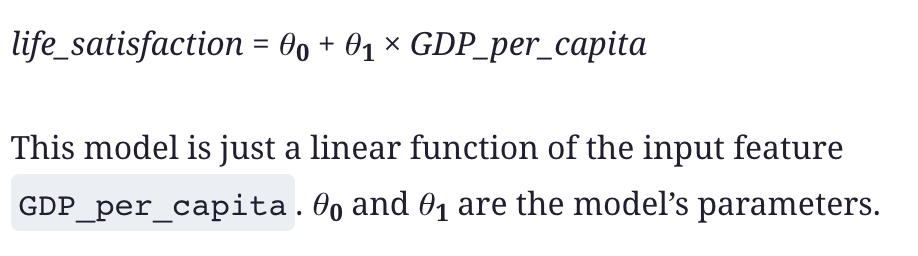

## Normal Equation

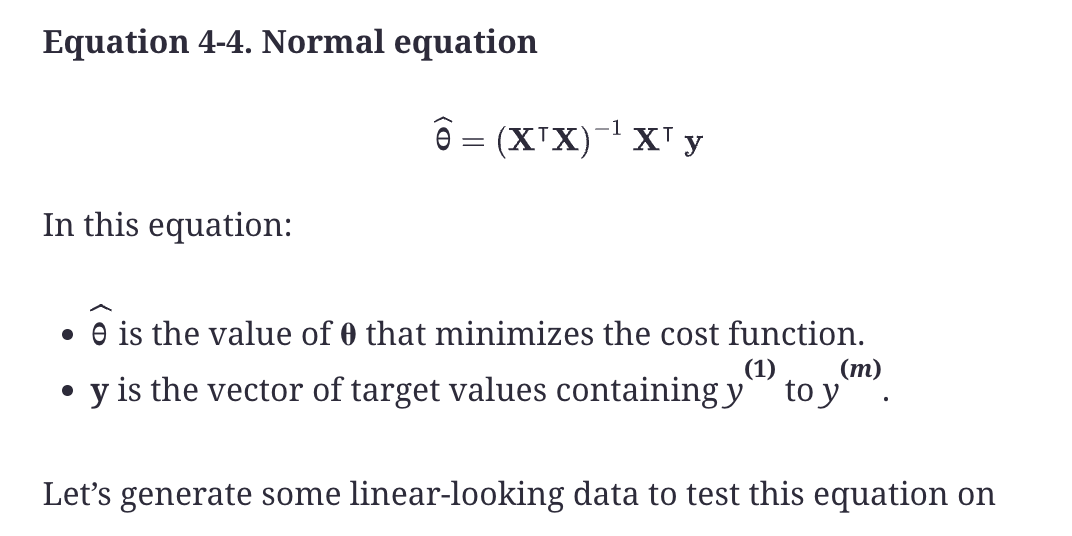

Shape of X: (100, 1)


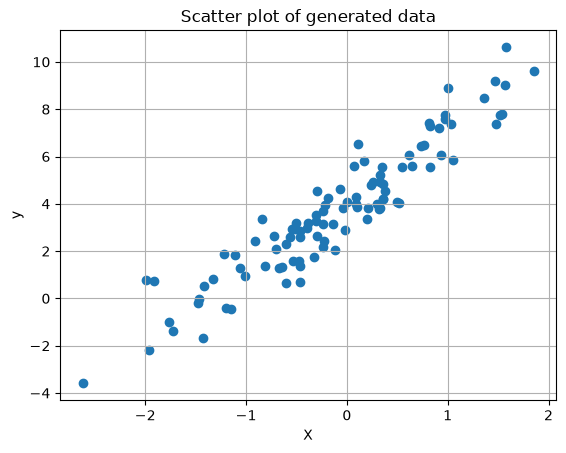

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility
m = 100
X = np.random.randn(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter plot of generated data")
plt.grid()
    
print("Shape of X:", X.shape)

In [32]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # Add bias term (intercept)
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.00742783],
       [2.85674284]])

In [33]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # Add bias term (intercept)
y_predict = X_new_b @ theta_best
y_predict

array([[4.00742783],
       [9.72091351]])

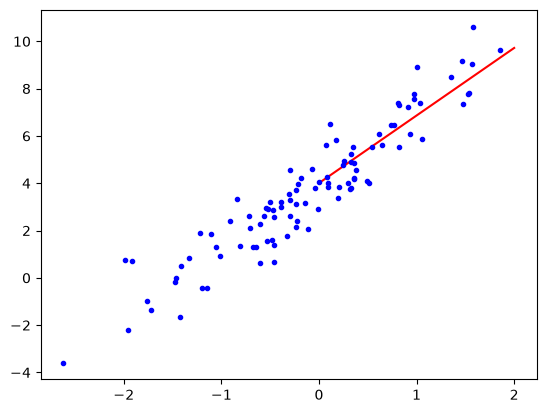

In [34]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

In [35]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.00742783]), array([[2.85674284]]))

In [36]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.00742783],
       [2.85674284]])

## Gradient Decent

- To implement gradient decent function, we need to cakculate how much the cost function will change if I change 0j little bit.
- This is called partial derivative

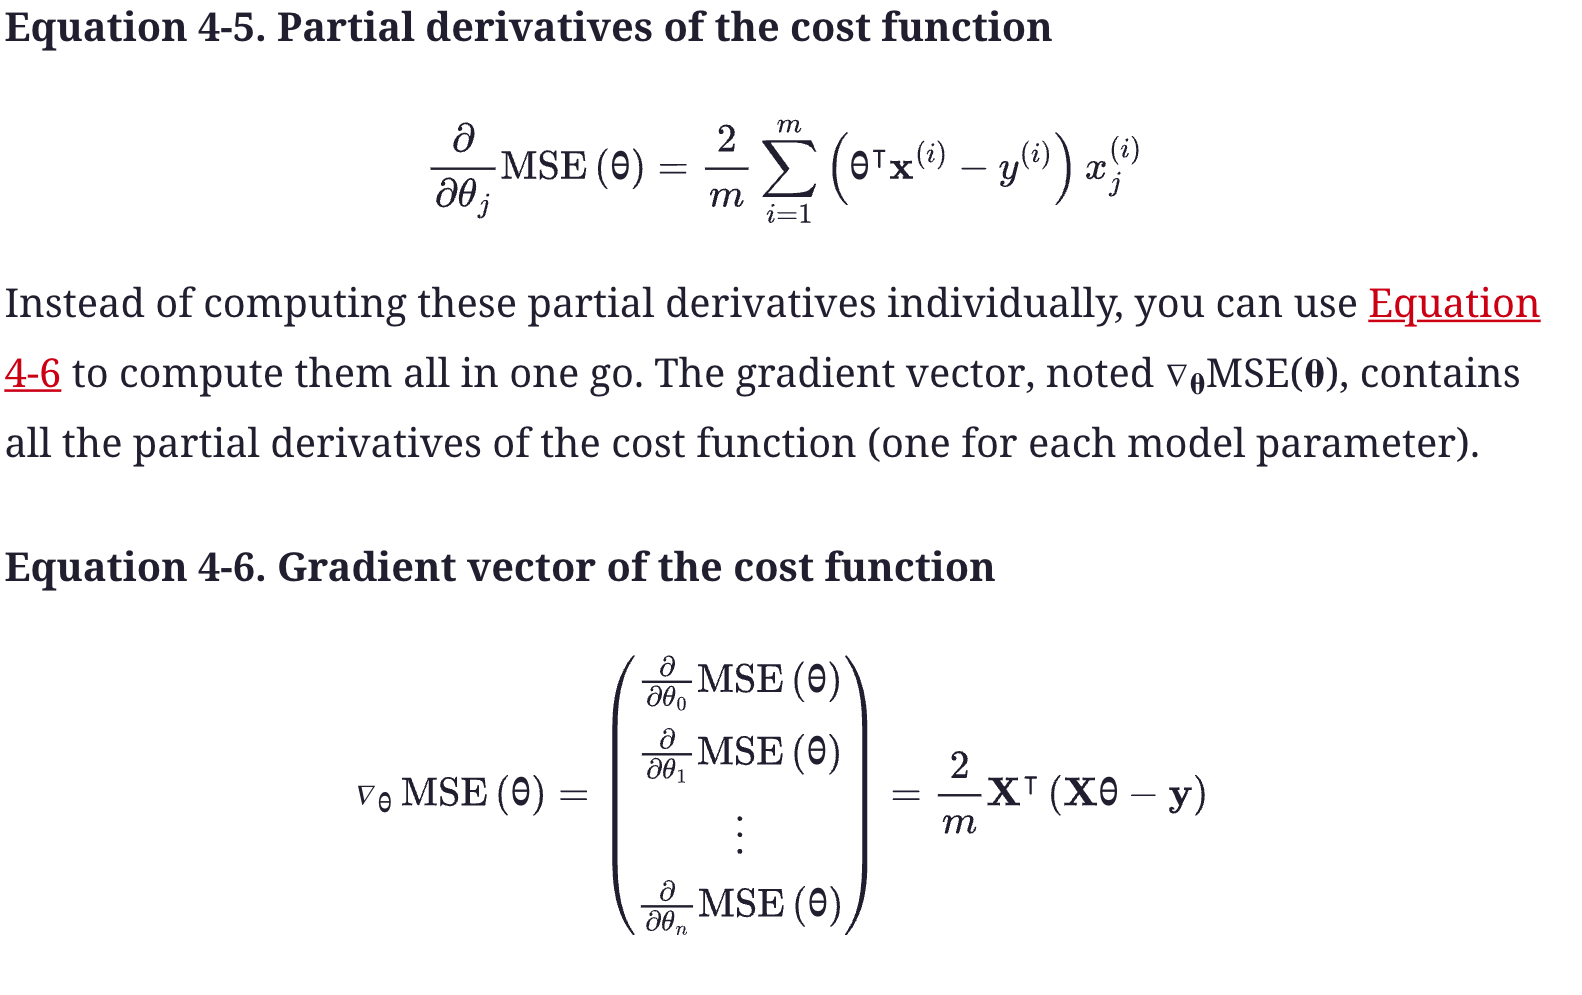

 - Once you have the gradient vector, which points uphill, just go in the opposite direction to go downhill. This means subtracting ∇θMSE(θ) from θ. This is where the learning rate η comes into play:⁠4 multiply the gradient vector by η to determine the size of the downhill step (Equation 4-7).
- 
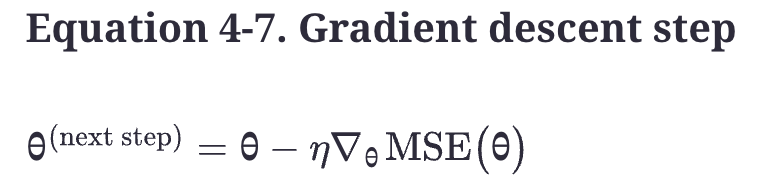

array([[4.0070379 ],
       [2.85594622]])

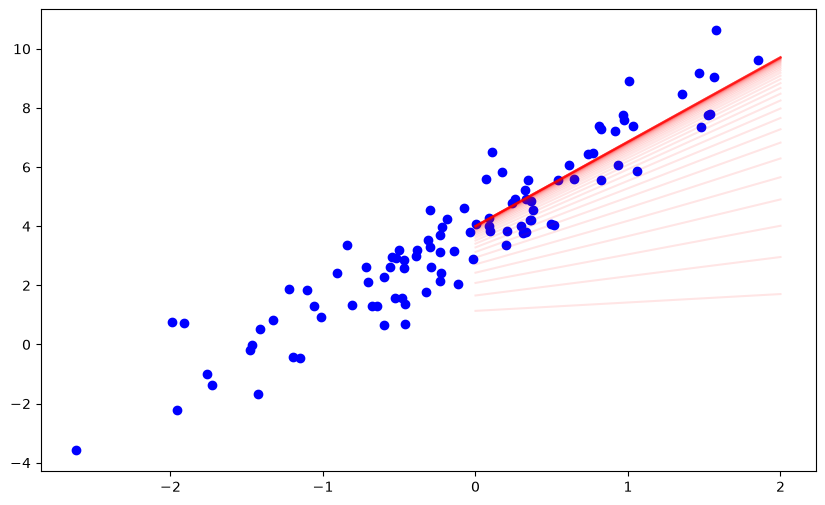

In [62]:
eta = 0.1  # Learning rate
n_epochs = 50

m = len(X_b)

np.random.seed(42)
theta = np.random.randn(2, 1)  # Random initialization

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')

for epoch in range(n_epochs):
    mse = np.mean((X_b.dot(theta) - y) ** 2)
    gradients = 2 / m * X_b.T.dot(X_b.dot(theta) - y)
    change = eta * gradients
    
    theta = theta - change
    plt.plot(X_new, X_new_b.dot(theta), "r-", alpha=0.1)  # Plot predictions with low opacity
 
    
    
theta

- if the number of epochs is too low, model parameters will be far away from optimal solution when algorithm stops
- if the number of epochs is too high, we will waste time and resources while model parameters dont change anymore
- so we set high number of epochs and define tolerance treshold to interrup training when gradient decent reached almost minimum

## Stoastic Gradient Decent

- Leaning rate scheduling 

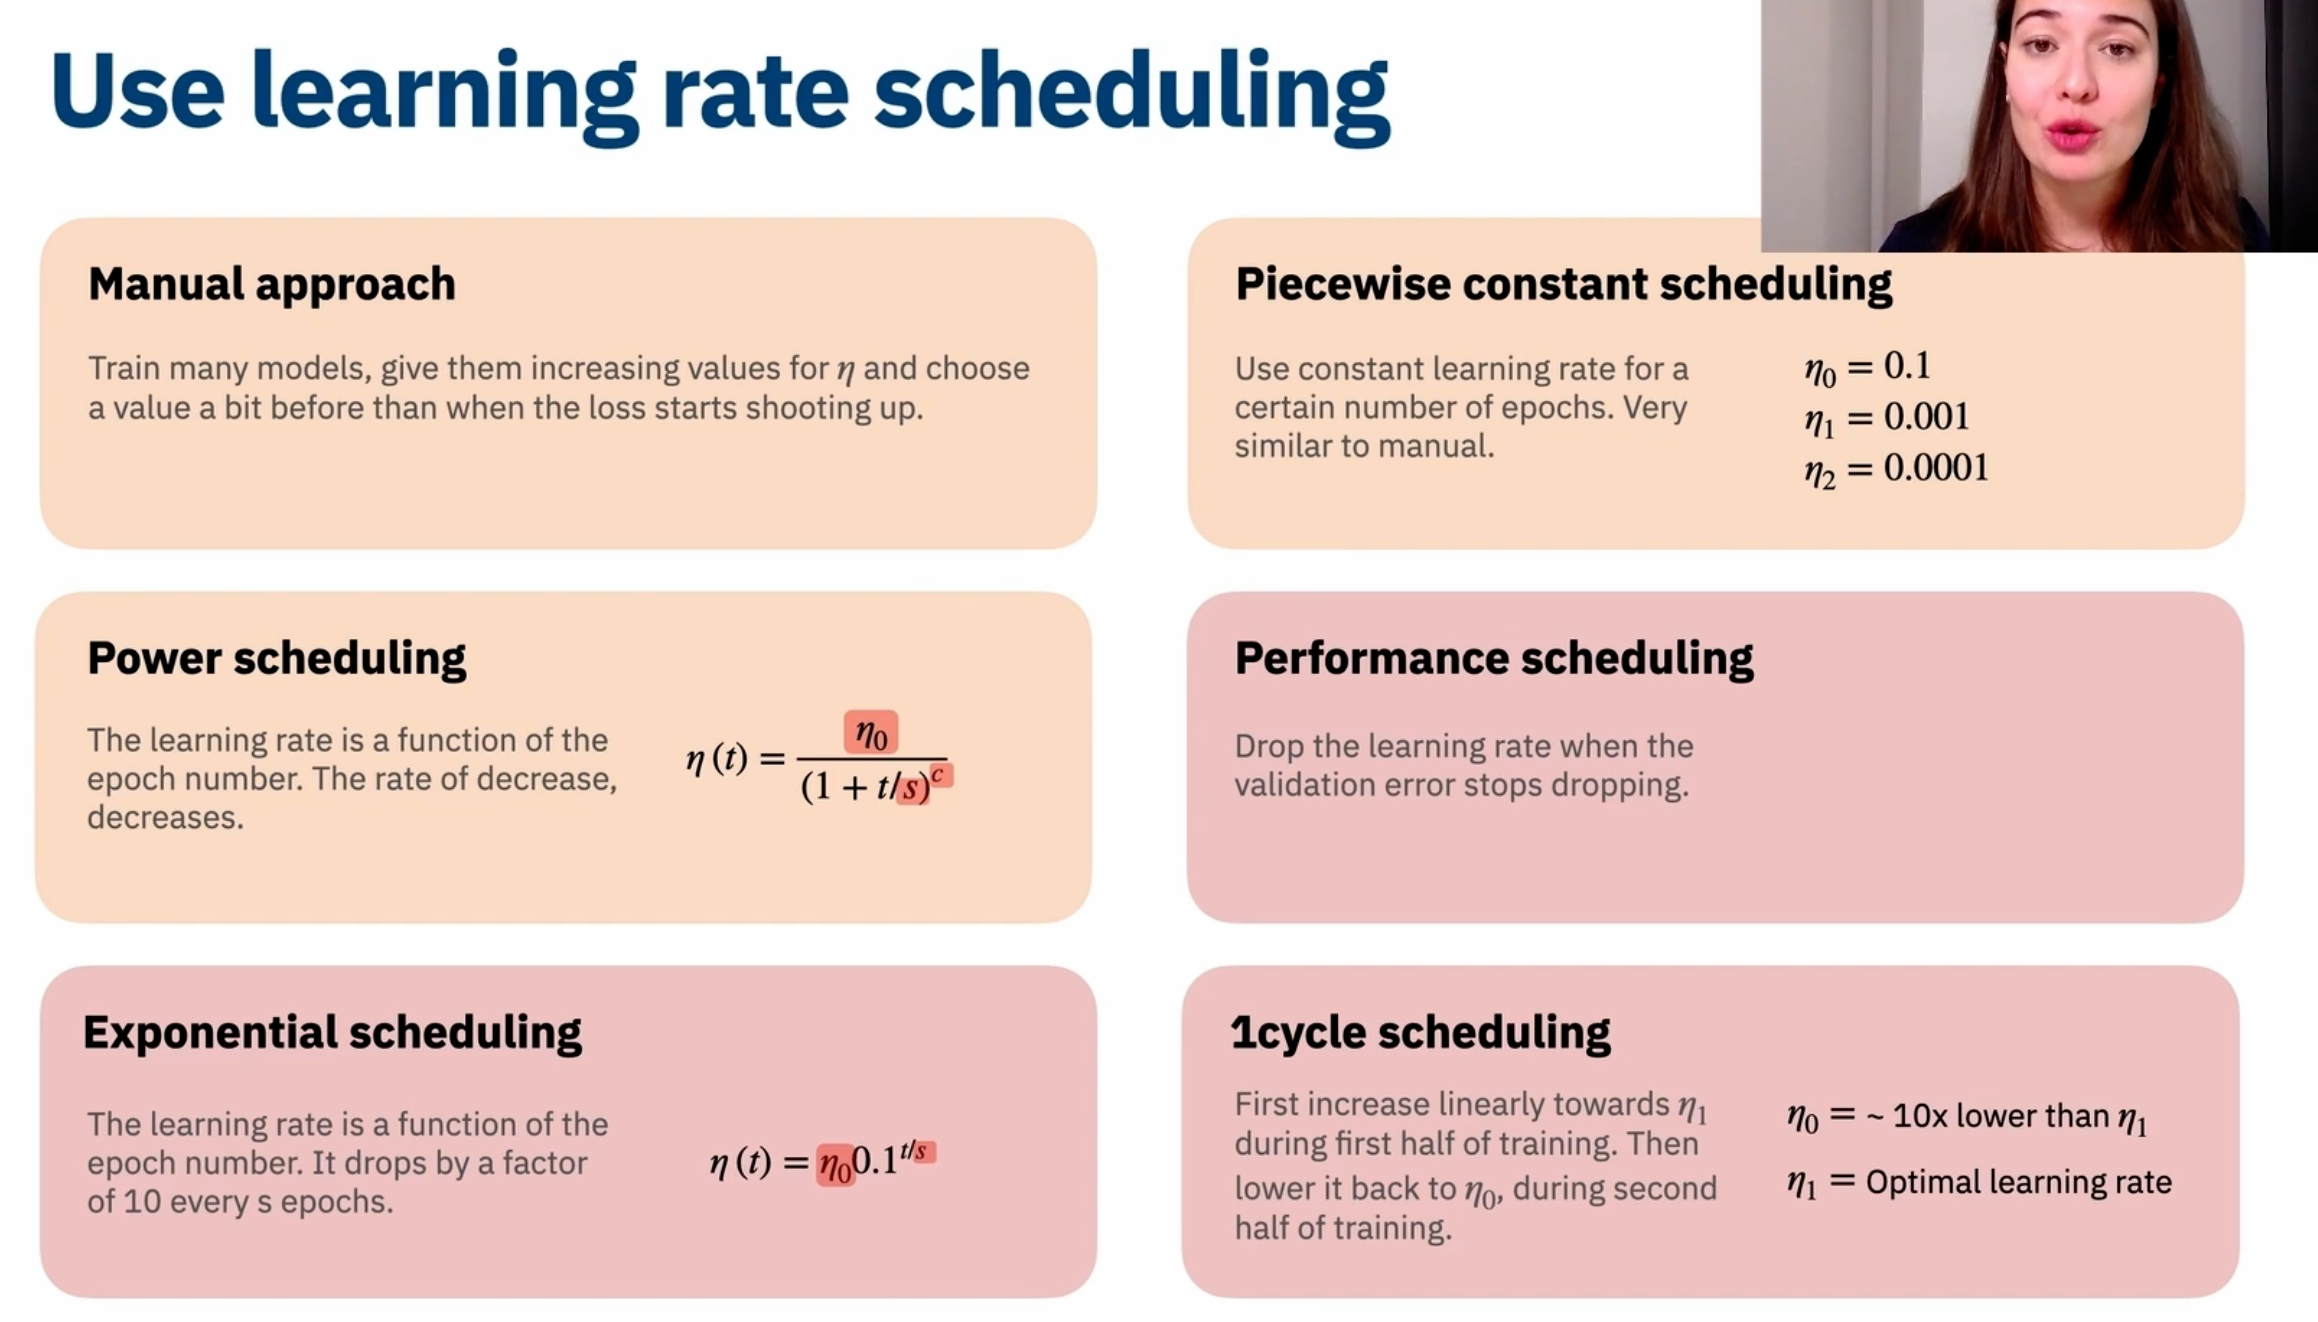

array([[4.04895841],
       [2.89159372]])

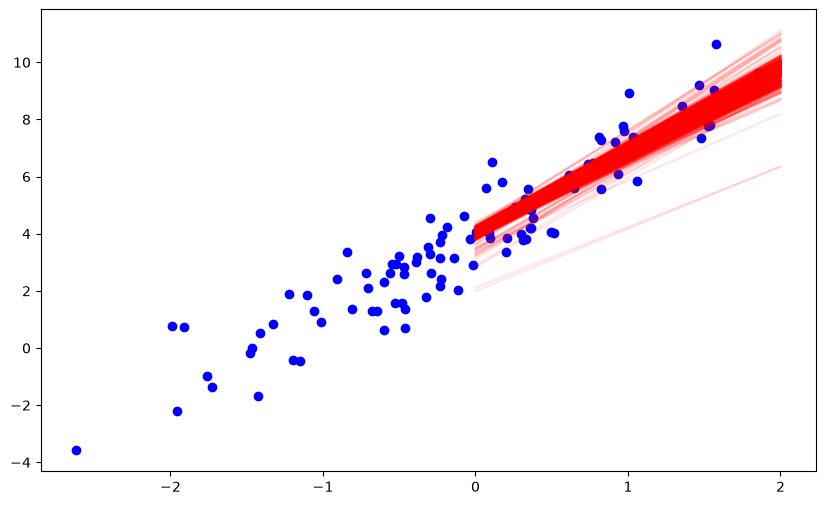

In [63]:
n_epochs = 50
t0, t1 = 5, 50  # Learning schedule hyperparameters

def learning_rate(epoch):
    return t0 / (epoch + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # Random initialization

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')


for epoch in range(n_epochs):
    for iteration in range(m):
        
        # Randomly select an index for stochastic gradient descent
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        
        # Compute the gradients and update theta
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        
        # Update theta using the learning rate schedule
        eta = learning_rate(epoch * m + iteration)
        
        # Update theta using the computed gradients and learning rate
        theta = theta - eta * gradients
        plt.plot(X_new, X_new_b.dot(theta), "r-", alpha=0.1)  # Plot predictions with low opacity
        
        
theta
        


- since we are choosing random instances to calculate gradient at each iteration, gradient decent does not linearly change but fluctuate always based on learning rate (eta) 
- this is the advantage of stoastic gradient decent algorithm as it can escape local minimums towards global minimum because
- <b>Note</b>: because natural and must behavour of SGD, the dataset must be shuffled by labels before training



In [65]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, random_state=42)
sgd_reg.fit(X, y.ravel())

,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.1
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0


- In Scikit-Learn, `SGDRegressor` does same job
- max_iter is at most number of epochs, tol is a tolerance threshold which helps interruption when needed gradient achieved
- eta is learning rate 
- `y.revel()` is needed because this model expects 1D array as labels
- To continue training later we can use `partial_fit()` instead of `fit()` method like `warm_start=True` hyperparameter which belongs to some models

## Mini-Batch gradient decent

- at every iteration just use random piece of training data instead of using whole dataset.
- this helps optimal training and bigger dataset usability

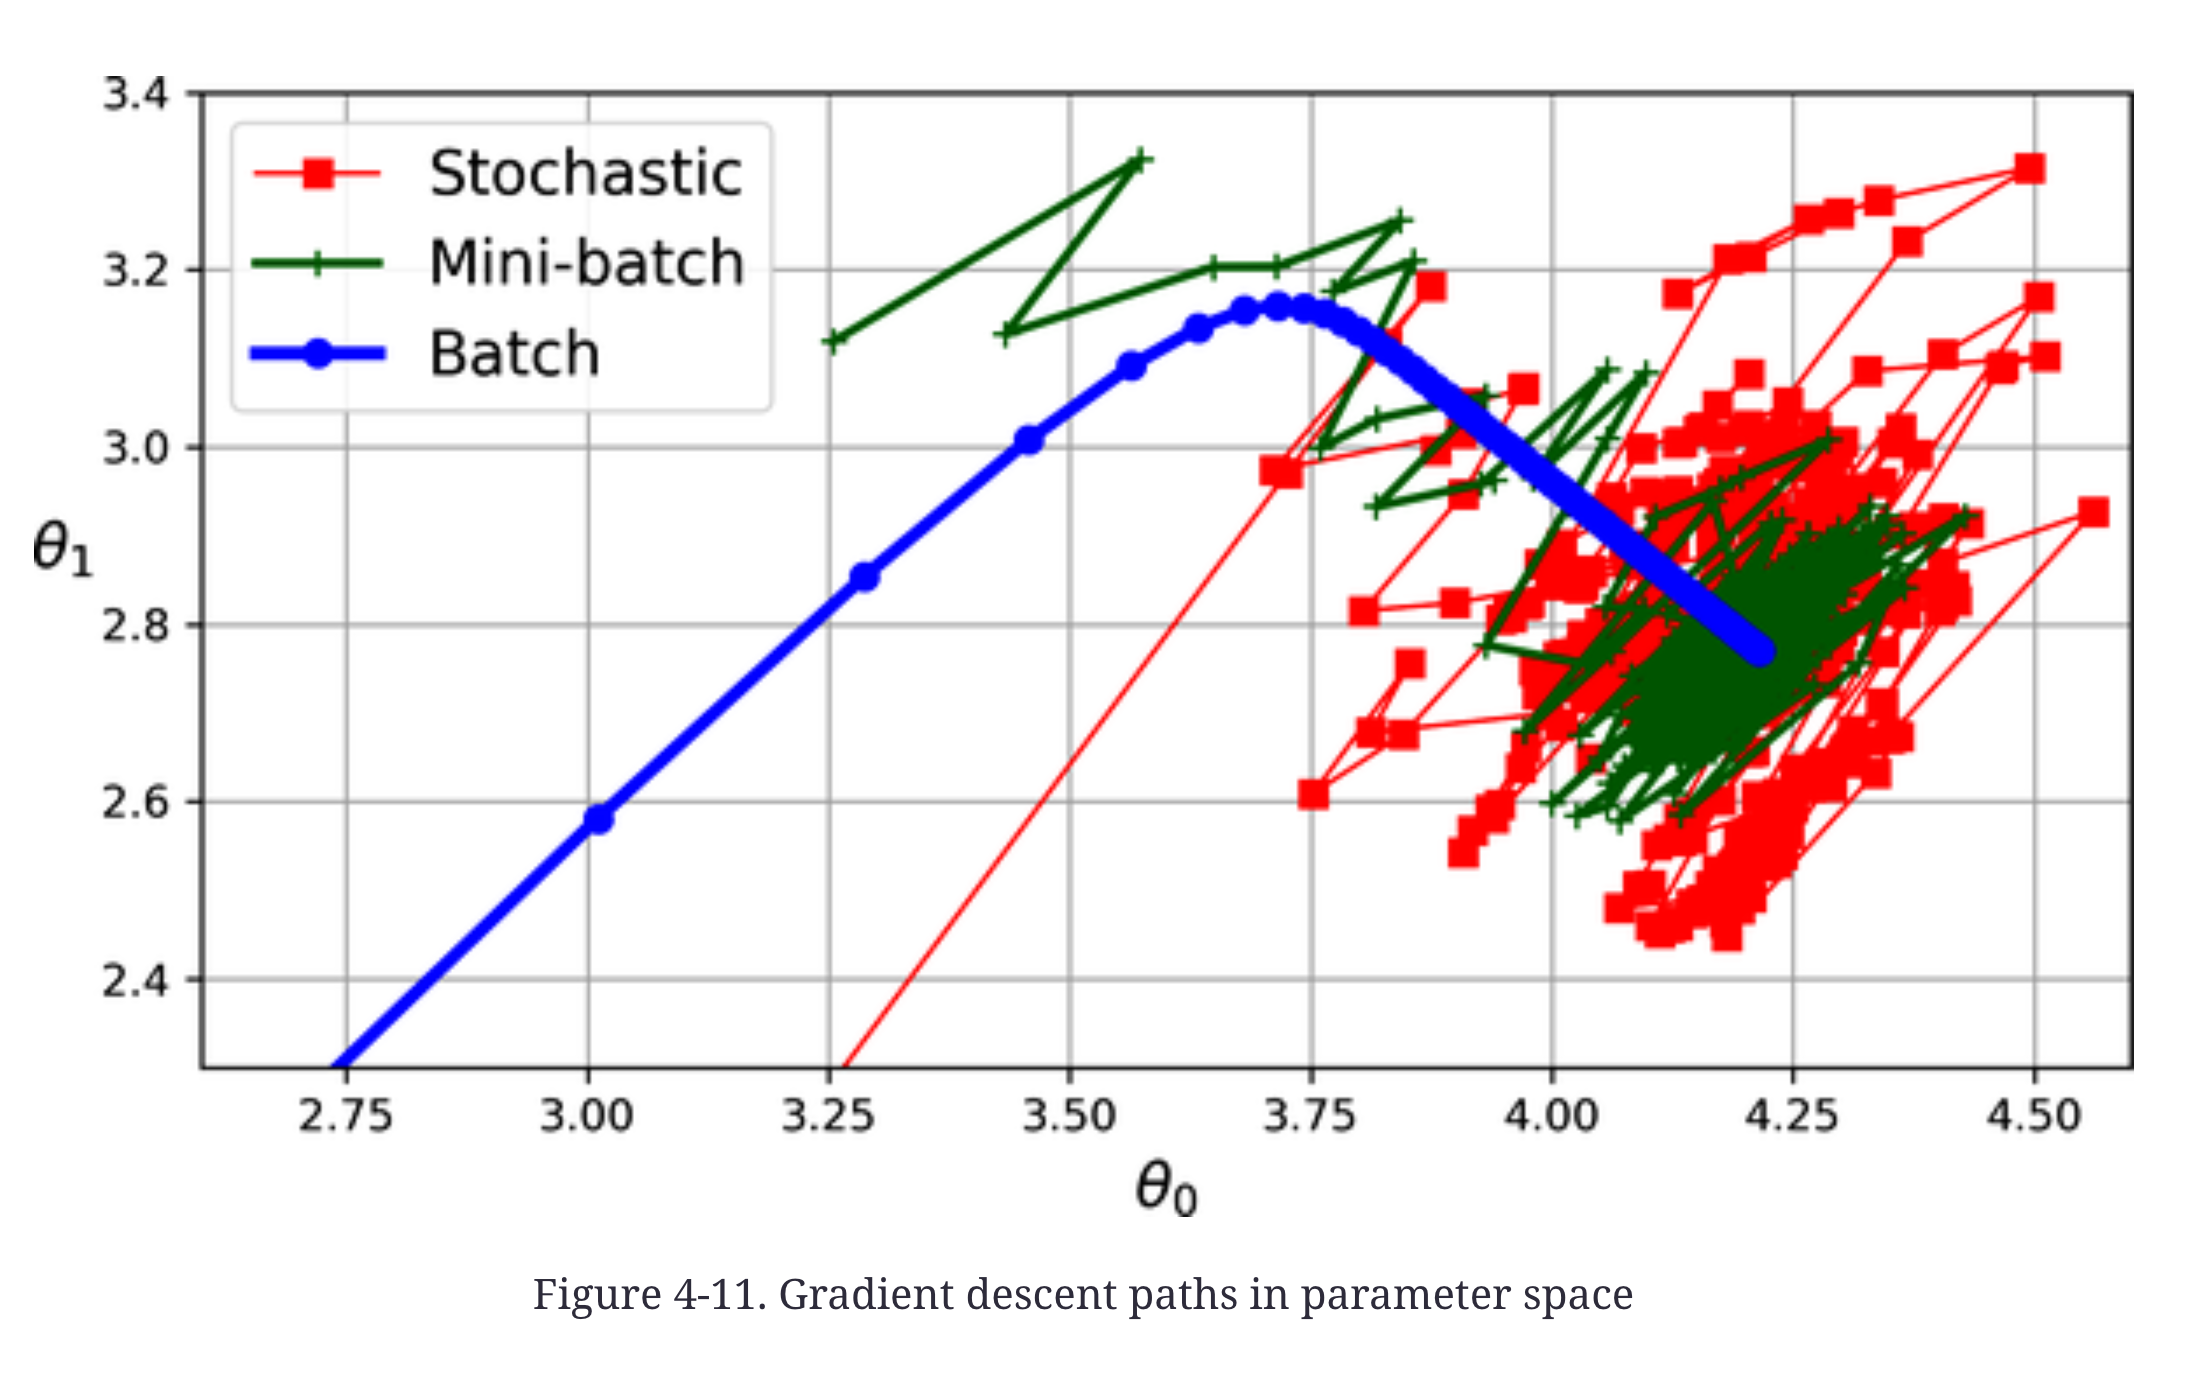

## Polynomial Regression

- Polynomial regression is a regression method that models a relationship between the input and target using polynomial terms, allowing it to fit nonlinear patterns in the data.
- Simple linear regression cannot adequately fit data with a curved relationship because it assumes the relationship between the input and target is a straight line.
- We can generate nonlinear, polynomial data using a quadratic equation with NumPy, for example:
y = 2x² + 3x + 5 + noise
- Polynomial regression is still linear regression with respect to its parameters. For example, y = β₀ + β₁x + β₂x² is nonlinear in x, but linear in the coefficients β₀, β₁, β₂.

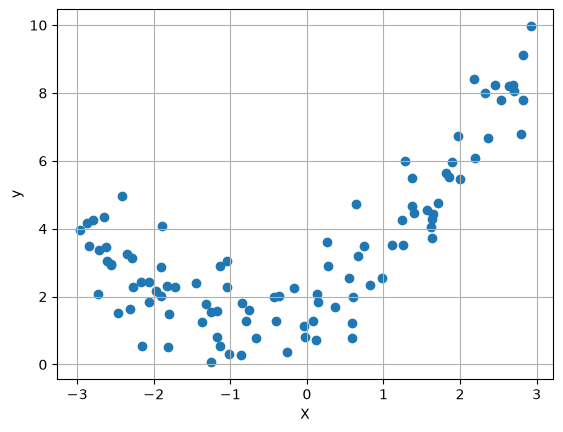

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.grid()
plt.show()

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred = lin_reg.predict(X)

print("Mean Squared Error (Linear Regression):", mean_squared_error(y, y_pred))

Mean Squared Error (Linear Regression): 3.0245639566396174


In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
poly_reg = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_reg.fit(X, y)
y_poly_pred = poly_reg.predict(X)

print("Mean Squared Error (Polynomial Regression):", mean_squared_error(y, y_poly_pred))

Mean Squared Error (Polynomial Regression): 0.7771936663502366


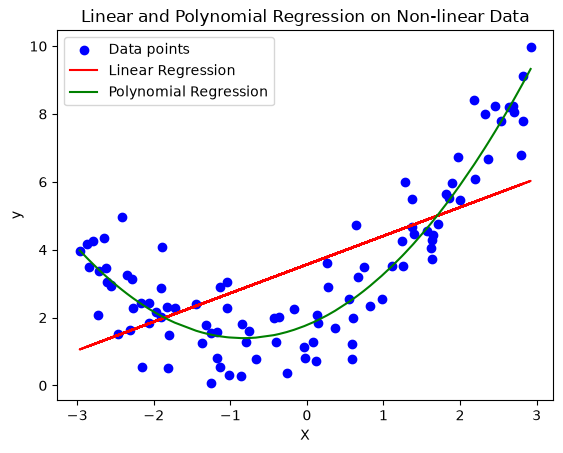

In [26]:
y_poly_pred = poly_reg.predict(X)

idx = np.argsort(X.ravel())

X_sorted = X[idx]
y_pred_poly_sorted = y_poly_pred[idx]

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred, color='red', label='Linear Regression')
plt.plot(X_sorted, y_pred_poly_sorted, color='green', label='Polynomial Regression')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear and Polynomial Regression on Non-linear Data")
plt.legend()
plt.show()

## Learning Curves

-  the learning curves, which are plots of the model’s training error and validation error as a function of the training iteration
- If the model cannot be trained incrementally (i.e., if it does not support partial_fit() or warm_start), then you must train it several times on gradually larger subsets of the training set.
- PyTorch does not have this `learning_curve` method built-in

In [ ]:
from sklearn.model_selection import learning_curve
from copy import deepcopy
def plot_lc(model, X, y):
    
    model = model.reset()  # Create a copy of the model to avoid modifying the original
    
    train_sizes, train_scores, valid_scores = learning_curve(
        model, X, y, cv=5, scoring='neg_root_mean_squared_error', train_sizes=np.linspace(0.01, 1.0, 40)
    )

    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)

    plt.plot(train_sizes, train_errors, "r-+", label='Training error')
    plt.plot(train_sizes, valid_errors, "b-", label='Validation error')
    plt.grid()
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.title("Learning Curve for Linear Regression")
    plt.legend()

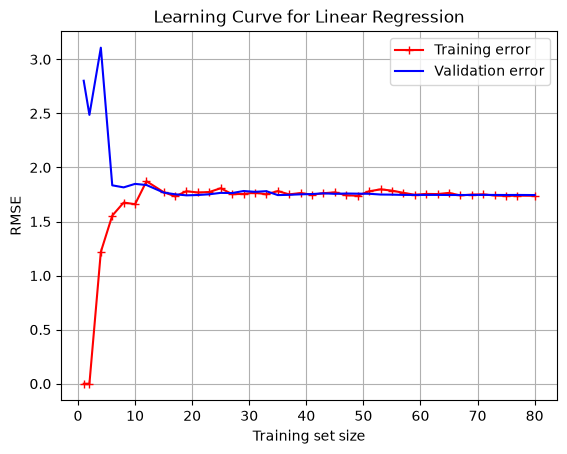

In [38]:

plot_lc(lin_reg, X, y)
plt.show()


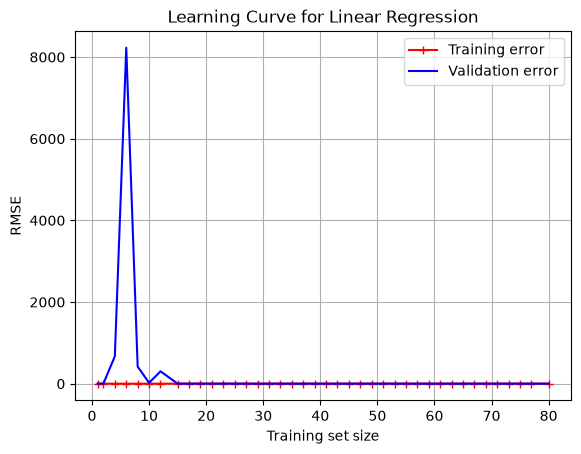

In [42]:
model = make_pipeline(PolynomialFeatures(degree=10, include_bias=False), LinearRegression())
plot_lc(model, X, y)
plt.show()

- The bias/variance tradeoff
1. Bias is an generalization error when there are wrong assumptions about data when choosing models 
2. variance is because of overcomplexity of the model which learns every datapoints without generalizing it
- So if variance is high, this effects generization/bias of the model. And same for when bias is high.
3. Irreducible error is when noiceness of data is high -> clean data or fix data sources

## Regularization

In [72]:
## Generating Linear Data
np.random.seed(42)  # For reproducibility
m = 100
X = np.random.randn(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

### Ridge Regression

In this type of regression, adds a regularization term to the cost function, and uses l2 norm of weight vectors in the fomula 

In [70]:
from sklearn.linear_model import Ridge, SGDRegressor

ridge_reg = Ridge(alpha=0.1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
print(y[5:6])
print(ridge_reg.predict(X[5:6]))

[[3.70163999]]
[3.33901404]


In [71]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.5 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
print(y[5:6])
print(sgd_reg.predict(X[5:6]))

[[3.70163999]]
[3.34155763]


### Lasso Regression

In this type of regression, adds a regularization term to the cost function, and uses l2 norm of weight vectors in the fomula
- can eliminate the  weights of least important features, by zeroing them, (Like `ReLU`)

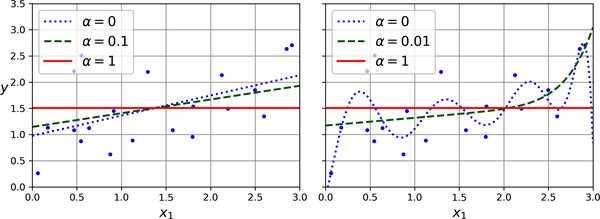

In [74]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
print(y[5:6])
print(lasso_reg.predict(X[5:6]))

[[3.70163999]]
[3.35451551]


In [75]:
sgd_reg = SGDRegressor(penalty="l1", alpha=0.1, tol=None, max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
print(y[5:6])
print(sgd_reg.predict(X[5:6]))

[[3.70163999]]
[3.3552284]


- if we set `penalty` hyperparameter of any model if exist euqal to `l1` or `l2`, that model then works like Lasso or Ridge regression 

### Elastic Regression 
Is a combination of ridge and lasso regression

In [76]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
print(y[5:6])
print(elastic_net.predict(X[5:6]))

[[3.70163999]]
[3.36755378]


## Early Stopping

- when gradient curve of validation set reaches to global minimum while training after certain epochs, and stats to go up again
- this means model startedto overfit, so we may wanna stop training here and assume this parameters in this iteration is the best
- however, in mini-batch gradient decent curves are not smooth, so can be difficult to know model GD reached global minimum or not
- to solve saving best paarameters at minimum GD in memory to roll back later if model could not find more minimums 

In [78]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

In [86]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)   # split the quadratic dataset

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')

val_errors = []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train.ravel())
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    val_errors.append(val_error)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)
        
print("Best validation RMSE:", best_valid_rmse, "at epoch", val_errors.index(best_valid_rmse)) 

Best validation RMSE: 0.7774374754877693 at epoch 385


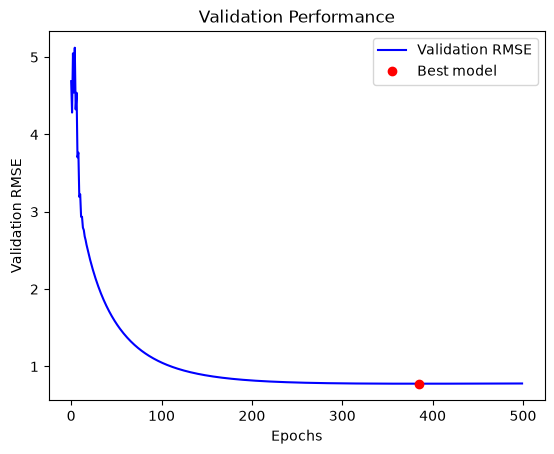

In [89]:
plt.plot(val_errors, "b-", label="Validation RMSE")
plt.plot(val_errors.index(best_valid_rmse), best_valid_rmse, "ro", label="Best model")
plt.xlabel("Epochs")
plt.ylabel("Validation RMSE")
plt.title("Validation Performance")
plt.legend()
plt.show() 

## Logistic Regression

- Some regression algorithms can be used for classification
- They predict probablity that an instance belongs to which class, and if that probablity higher than fixed threshold, then that class will be out

In [91]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [92]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


X = iris.data[["petal width (cm)"]].values 
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

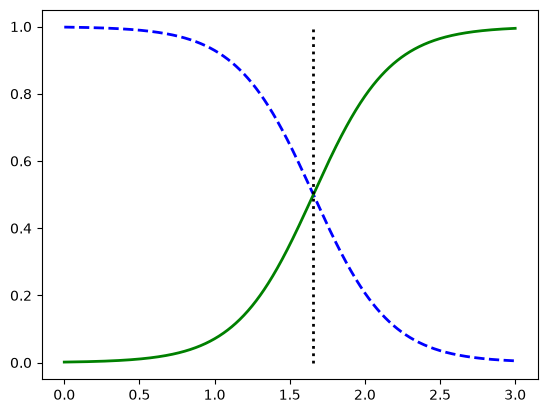

In [99]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

- after classifier model trained, it has got decision boundary which is used for as threshold value when problities evaluated
- in this case, decision boundary is at ~1.6 for X, so any input less than this will be False, more than will be True

In [102]:
print("Decision boundary at petal width:", decision_boundary)
log_reg.predict([[1.7], [1.5], [1.0], [2.0]])

Decision boundary at petal width: 1.6576576576576576


array([ True, False, False,  True])

## Multinomial Logistic Regression / Softmax Regression

- This Logistic Regression is often used for multiclass classification not multioutput
- how it works:
 1. calculate dot product of that transpose of weight and input vector (x) of the given k th class -> linear score of k class
 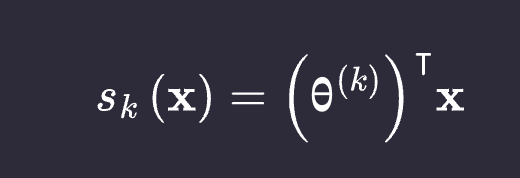
 2. divide the exponential of linear score of k by the sum of linear scores of all other classes -> probablity for each class -> sum is = 1
 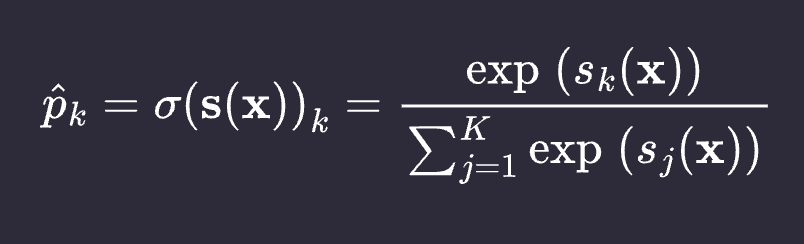
 3. 1. Training uses cross entropy loss function to minimize error which embeds softmax function 
 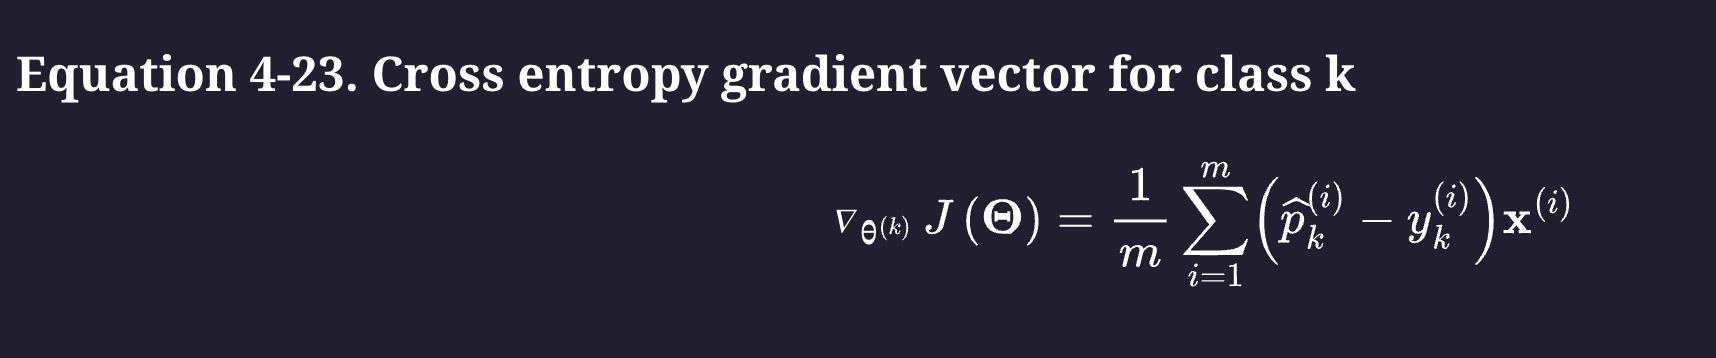
 3. 2.Prediction: use argmax function to predict biggest probablity score among K class scores calculated using softmax function
 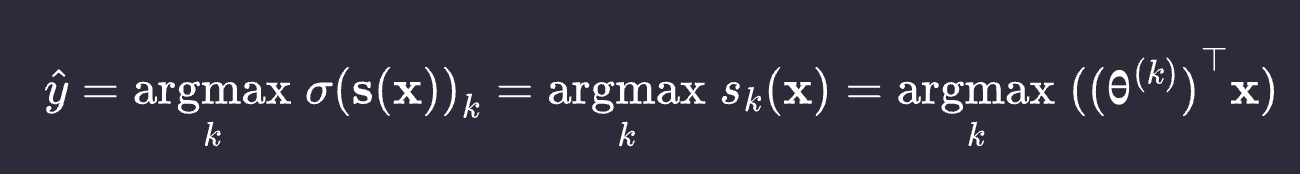


- Okay we learned how softmax function works, but how we can minimize this cost function ??? 
- In detail, first step uses weights so we need to optimize that weights to achieve minimal error in evaluation 

In this chapter, we learned various ways to train linear models, both for regression and for classification. We used a closed-form equation to solve linear regression, as well as gradient descent, and we learned how various penalties can be added to the cost function during training to regularize the model. Along the way, we also learned how to plot learning curves and analyze them, and how to implement early stopping. Finally, we learned how logistic regression and softmax regression work. We’ve opened up the first machine learning black boxes! In the next chapters we will open many more, starting with support vector machines.

# Exercises

1. Which linear regression training algorithm can you use if you have a training set with millions of features?

Stoastic or Mini-batch GD algorithms are useful because they avoid training whole dataset at a time

2. Linear models can suffer from features having very different scales, especially when trained with gradient descent. The loss surface becomes elongated, causing gradient descent to take inefficient, zigzagging steps and converge slowly. The standard solution is to standardize the features, typically using StandardScaler

3. No. Logistic Rgeression is an convex function so it doesn not have local minimum 

4. No, because different gradient descent algorithms can converge differently, and some may fail to converge if the learning rate is inappropriate.


